# 08 Baseline D2: Decade × Subfield Baseline

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '08_baseline_d2_subfield_topic'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
def standardize_edges(edges):
    out = edges[['citing_paper_id', 'cited_paper_id']].copy()
    out['citing_paper_id'] = out['citing_paper_id'].astype(str)
    out['cited_paper_id'] = out['cited_paper_id'].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
    cs_papers = pd.read_pickle(PROCESSED_DIR / 'cs_papers_final.pkl')
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl'))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl'))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl'))
    papers['id'] = papers['id'].astype(str)
    cs_papers['id'] = cs_papers['id'].astype(str)
    return (papers, cs_papers, all_edges, all_to_cs, cs_to_cs)

def known_cs(cs_papers):
    return cs_papers[cs_papers['first_last_cat'].isin(GENDER_CATEGORIES)].copy()

def aggregate_oe(observed, expected, baseline, citation_slice):
    rows = []
    for g in GENDER_CATEGORIES:
        o = float(observed.get(g, 0.0))
        e = float(expected.get(g, 0.0))
        oe = o / e if e > 0 else np.nan
        rows.append({'gender_cat': g, 'observed_citations': o, 'expected_citations': e, 'oe_ratio': oe, 'pct_diff_from_expected': (oe - 1.0) * 100 if pd.notna(oe) else np.nan, 'baseline': baseline, 'citation_slice': citation_slice})
    return pd.DataFrame(rows)

def prepare_cited_edges(edges, cs_known, extra_cols):
    meta_cols = ['id', 'first_last_cat'] + list(extra_cols)
    meta = cs_known[meta_cols].drop_duplicates('id').rename(columns={'id': 'cited_paper_id', 'first_last_cat': 'cited_gender'})
    return edges.merge(meta, on='cited_paper_id', how='inner')

In [3]:
def stratified_expected(cs_known, edges, strata_cols, baseline_name, citation_slice):
    shares = cs_known.groupby(strata_cols + ['first_last_cat'], dropna=False).size().rename('n').reset_index()
    totals = shares.groupby(strata_cols, dropna=False)['n'].transform('sum')
    shares['share'] = shares['n'] / totals
    share_wide = shares.pivot_table(index=strata_cols, columns='first_last_cat', values='share', fill_value=0, dropna=False).reindex(columns=GENDER_CATEGORIES, fill_value=0).reset_index()
    cited = prepare_cited_edges(edges, cs_known, strata_cols)
    cited = cited.merge(share_wide, on=strata_cols, how='left')
    observed = cited['cited_gender'].value_counts().reindex(GENDER_CATEGORIES, fill_value=0)
    expected = cited[GENDER_CATEGORIES].sum().reindex(GENDER_CATEGORIES, fill_value=0)
    result = aggregate_oe(observed, expected, baseline_name, citation_slice)
    return (result, cited, share_wide)

## 1. Load final data

In [4]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
cs_known = known_cs(cs_papers)
print('Known-gender CS papers:', cs_known.shape)

Known-gender CS papers: (1081363, 29)


## 2. Main D2: decade × subfield

In [5]:
d2_all, d2_all_edges, d2_subfield_shares = stratified_expected(cs_known, edges_all_to_cs, ['decade', 'primary_subfield'], 'D2_decade_subfield', 'All→CS')
d2_cs, d2_cs_edges, _ = stratified_expected(cs_known, edges_cs_to_cs, ['decade', 'primary_subfield'], 'D2_decade_subfield', 'CS→CS')
d2_results = pd.concat([d2_all, d2_cs], ignore_index=True)
d2_results

,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice
0,MM,"6,942,653.0000","6,666,917.5180",1.0414,4.1359,D2_decade_subfield,All→CS
1,MW,"641,435.0000","685,698.6479",0.9354,-6.4553,D2_decade_subfield,All→CS
2,WM,"812,529.0000","927,003.9420",0.8765,-12.3489,D2_decade_subfield,All→CS
3,WW,"289,620.0000","406,616.8921",0.7123,-28.7732,D2_decade_subfield,All→CS
4,MM,"5,601,920.0000","5,393,689.5841",1.0386,3.8606,D2_decade_subfield,CS→CS
5,MW,"529,022.0000","553,955.9290",0.9550,-4.5011,D2_decade_subfield,CS→CS
6,WM,"662,200.0000","747,784.2106",0.8855,-11.4450,D2_decade_subfield,CS→CS
7,WW,"230,358.0000","328,070.2763",0.7022,-29.7839,D2_decade_subfield,CS→CS


## 3. Topic sensitivity (not the primary D2 specification)

In [6]:
topic_col = 'primary_topic_name'
d2_topic_all, _, _ = stratified_expected(cs_known, edges_all_to_cs, ['decade', topic_col], 'D2_topic_sensitivity', 'All→CS')
d2_topic_cs, _, _ = stratified_expected(cs_known, edges_cs_to_cs, ['decade', topic_col], 'D2_topic_sensitivity', 'CS→CS')
d2_topic_results = pd.concat([d2_topic_all, d2_topic_cs], ignore_index=True)
d2_topic_results

,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice
0,MM,"6,942,653.0000","6,675,527.5784",1.0400,4.0016,D2_topic_sensitivity,All→CS
1,MW,"641,435.0000","691,741.7432",0.9273,-7.2725,D2_topic_sensitivity,All→CS
2,WM,"812,529.0000","935,471.9013",0.8686,-13.1423,D2_topic_sensitivity,All→CS
3,WW,"289,620.0000","383,495.7771",0.7552,-24.4790,D2_topic_sensitivity,All→CS
4,MM,"5,601,920.0000","5,396,665.5245",1.0380,3.8034,D2_topic_sensitivity,CS→CS
5,MW,"529,022.0000","560,222.8415",0.9443,-5.5694,D2_topic_sensitivity,CS→CS
6,WM,"662,200.0000","756,677.6783",0.8751,-12.4859,D2_topic_sensitivity,CS→CS
7,WW,"230,358.0000","309,933.9557",0.7432,-25.6751,D2_topic_sensitivity,CS→CS


## 4. Visualize main D2

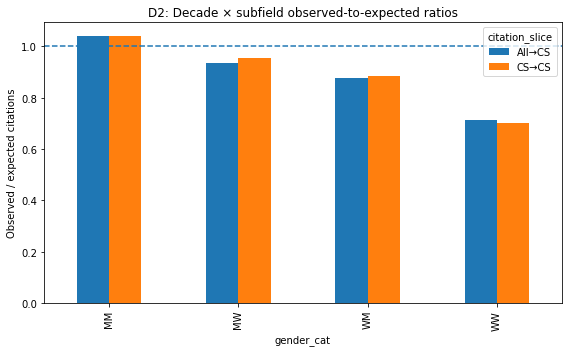

In [7]:
plot = d2_results.pivot(index='gender_cat', columns='citation_slice', values='oe_ratio').reindex(GENDER_CATEGORIES)
ax = plot.plot(kind='bar', figsize=(8, 5))
ax.axhline(1.0, linestyle='--')
ax.set_ylabel('Observed / expected citations')
ax.set_title('D2: Decade × subfield observed-to-expected ratios')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d2_decade_subfield_slice_comparison.png', dpi=300)
plt.show()

## 5. Save outputs

In [8]:
d2_all.to_csv(TABLE_DIR / 'baseline_d2_decade_subfield_all_to_cs.csv', index=False)
d2_cs.to_csv(TABLE_DIR / 'baseline_d2_decade_subfield_cs_to_cs.csv', index=False)
d2_results.to_csv(TABLE_DIR / 'baseline_d2_decade_subfield_slice_comparison.csv', index=False)
d2_results.to_csv(TABLE_DIR / 'd2_decade_subfield_oe_by_gender.csv', index=False)
d2_topic_results.to_csv(TABLE_DIR / 'd2_topic_sensitivity_oe_by_gender.csv', index=False)
print('Saved:', NOTEBOOK_OUTPUT_DIR)

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\08_baseline_d2_subfield_topic
